In [1]:
import os
import librosa
import numpy as np
import pandas as pd
import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    LSTM,
    Input,
    LayerNormalization,
    MultiHeadAttention,
    GlobalAveragePooling1D,
    Add
)

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
DATASET_PATH = kagglehub.dataset_download("uwrfkaggler/ravdess-emotional-speech-audio")

Using Colab cache for faster access to the 'ravdess-emotional-speech-audio' dataset.


In [3]:
emotion_map = {
    "01":"neutral",
    "02":"calm",
    "03":"happy",
    "04":"sad",
    "05":"angry",
    "06":"fearful",
    "07":"disgust",
    "08":"surprised"
}

In [4]:
def extract_features(file_path):

    audio, sr = librosa.load(
        file_path,
        duration=3,
        offset=0.5
    )

    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=sr,
        n_mfcc=40
    )

    return mfcc.T

In [5]:
X = []
y = []

for actor in os.listdir(DATASET_PATH):

    actor_path = os.path.join(DATASET_PATH, actor)

    if not os.path.isdir(actor_path):
        continue

    for file in os.listdir(actor_path):

        if file.endswith(".wav"):

            emotion_code = file.split("-")[2]

            feature = extract_features(
                os.path.join(actor_path,file)
            )

            X.append(feature)
            y.append(emotion_map[emotion_code])

In [6]:
max_len = max([x.shape[0] for x in X])

X_pad = []

for sample in X:

    pad = max_len - sample.shape[0]

    sample = np.pad(
        sample,
        ((0,pad),(0,0)),
        mode="constant"
    )

    X_pad.append(sample)

X = np.array(X_pad)

print(X.shape)

(1440, 130, 40)


In [7]:
encoder = LabelEncoder()

y = encoder.fit_transform(y)

y = to_categorical(y)

print(y.shape)

(1440, 8)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [9]:
lstm_model = Sequential()

lstm_model.add(
    LSTM(
        128,
        return_sequences=True,
        input_shape=(X.shape[1], X.shape[2])
    )
)

lstm_model.add(Dropout(0.3))

lstm_model.add(LSTM(64))

lstm_model.add(Dropout(0.3))

lstm_model.add(Dense(32, activation="relu"))

lstm_model.add(Dense(8, activation="softmax"))

lstm_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 130, 128)       │        86,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 130, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           264 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,280 (540.16 KB)

 Trainable params: 138,280 (540.16 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
history_lstm = lstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_test,y_test),
    epochs=30,
    batch_size=32
)

Epoch 1/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.1415 - loss: 2.0688 - val_accuracy: 0.2118 - val_loss: 1.9908
Epoch 2/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.2292 - loss: 1.9530 - val_accuracy: 0.2743 - val_loss: 1.8779
Epoch 3/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.2865 - loss: 1.8497 - val_accuracy: 0.3368 - val_loss: 1.8491
Epoch 4/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.3186 - loss: 1.7738 - val_accuracy: 0.3507 - val_loss: 1.6786
Epoch 5/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.3646 - loss: 1.6712 - val_accuracy: 0.3819 - val_loss: 1.6257
Epoch 6/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.3802 - loss: 1.6033 - val_accuracy: 0.4306 - val_loss: 1.5585
Epoch 7/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.4210 - loss: 1.5351 - val_accuracy: 0.3646 - val_loss: 1.7074
Epoch 8/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.4514 - loss: 1.4891 - val_accuracy: 0.4271 - v

In [11]:
lstm_loss, lstm_acc = lstm_model.evaluate(
    X_test,
    y_test
)

print("LSTM Accuracy:", lstm_acc)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5938 - loss: 1.2209
LSTM Accuracy: 0.59375


In [12]:
#transformer model

In [13]:
def transformer_encoder(inputs,
                        head_size,
                        num_heads,
                        ff_dim,
                        dropout=0):

    x = LayerNormalization(epsilon=1e-6)(inputs)

    x = MultiHeadAttention(
        key_dim=head_size,
        num_heads=num_heads,
        dropout=dropout
    )(x,x)

    x = Dropout(dropout)(x)

    res = Add()([x, inputs])

    x = LayerNormalization(epsilon=1e-6)(res)

    x = Dense(ff_dim, activation="relu")(x)

    x = Dropout(dropout)(x)

    x = Dense(inputs.shape[-1])(x)

    return Add()([x,res])

In [14]:
inputs = Input(
    shape=(X.shape[1], X.shape[2])
)

x = transformer_encoder(
    inputs,
    head_size=64,
    num_heads=4,
    ff_dim=128,
    dropout=0.2
)

x = transformer_encoder(
    x,
    head_size=64,
    num_heads=4,
    ff_dim=128,
    dropout=0.2
)

x = GlobalAveragePooling1D()(x)

x = Dense(128, activation="relu")(x)

x = Dropout(0.3)(x)

outputs = Dense(
    8,
    activation="softmax"
)(x)

transformer_model = Model(
    inputs,
    outputs
)

transformer_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

transformer_model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 130, 40)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 130, 40)   │         80 │ input_layer_1[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 130, 40)   │     41,768 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 130, 40)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 130, 40)   │          0 │ dropout_3[0][0],  │
│                     │                   │            │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 130, 40)   │         80 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 130, 128)  │      5,248 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 130, 128)  │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 130, 40)   │      5,160 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 130, 40)   │          0 │ dense_3[0][0],    │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 130, 40)   │         80 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 130, 40)   │     41,768 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 130, 40)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 130, 40)   │          0 │ dropout_6[0][0],  │
│                     │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 130, 40)   │         80 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 130, 128)  │      5,248 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 130, 128)  │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 130, 40)   │      5,160 │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 130, 40)   │          0 │ dense_5[0][0],    │
│                     │                   │            │ add_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 110,952 (433.41 KB)

 Trainable params: 110,952 (433.41 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
history_transformer = transformer_model.fit(
    X_train,
    y_train,
    validation_data=(X_test,y_test),
    epochs=30,
    batch_size=32
)

Epoch 1/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 16s 47ms/step - accuracy: 0.1128 - loss: 62.9127 - val_accuracy: 0.1285 - val_loss: 11.1139
Epoch 2/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.1415 - loss: 38.9011 - val_accuracy: 0.1910 - val_loss: 6.0099
Epoch 3/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1849 - loss: 13.3581 - val_accuracy: 0.1979 - val_loss: 2.9724
Epoch 4/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2188 - loss: 2.3521 - val_accuracy: 0.2049 - val_loss: 1.9379
Epoch 5/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2309 - loss: 1.9291 - val_accuracy: 0.1875 - val_loss: 1.9420
Epoch 6/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2396 - loss: 1.9115 - val_accuracy: 0.2326 - val_loss: 1.9075
Epoch 7/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2500 - loss: 1.8880 - val_accuracy: 0.2326 - val_loss: 1.8571
Epoch 8/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.2335 - loss: 1.8846 - val_accuracy: 0.281

In [16]:
tr_loss, tr_acc = transformer_model.evaluate(
    X_test,
    y_test
)

print("Transformer Accuracy:", tr_acc)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3472 - loss: 1.6290 
Transformer Accuracy: 0.3472222089767456


In [17]:
results = pd.DataFrame({

    "Model":[
        "LSTM",
        "Transformer"
    ],

    "Accuracy":[
        lstm_acc,
        tr_acc
    ]
})

print(results)

         Model  Accuracy
0         LSTM  0.593750
1  Transformer  0.347222


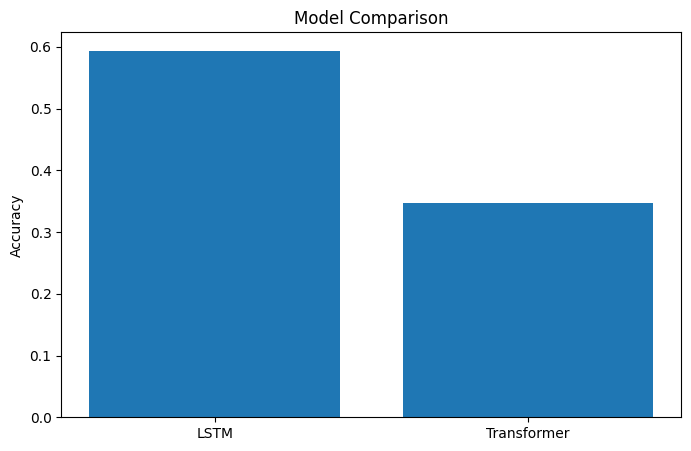

In [18]:
plt.figure(figsize=(8,5))

plt.bar(
    results["Model"],
    results["Accuracy"]
)

plt.title("Model Comparison")
plt.ylabel("Accuracy")

plt.show()

9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step


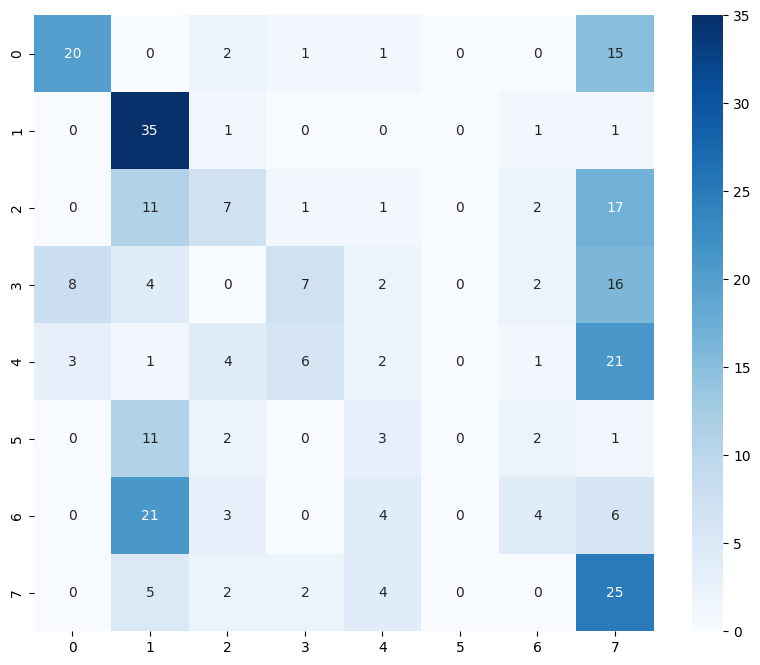

In [19]:
pred = transformer_model.predict(X_test)

y_pred = np.argmax(pred, axis=1)

y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.show()